<a href="https://colab.research.google.com/github/gayathri9381/TNS.ipynb/blob/main/EDA%26Outliers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) is the process of analyzing and summarizing a cleaned dataset to understand its patterns, distributions, relationships, and characteristics before building Machine Learning models.

#Outliers
An outlier is a value that is unusually high or unusually low compared to the rest of the data.

An outlier is a data value that is significantly different from the other values in the dataset.

Example:

25, 28, 30, 32, 35, 36, 38, 250

Here, 250 is an outlier because it is much larger than the other values.
Step 2: Arrange the Data

Before finding outliers, arrange the data in ascending order.

Example

10 15 18 20 22 24 26 30 35
Step 3: Calculate Quartiles

Quartiles divide the dataset into four equal parts.

Minimum

↓

Q1 (25%)

↓

Q2 (Median - 50%)

↓

Q3 (75%)

↓

Maximum
Q1 (First Quartile)
25% of the data lies below Q1.
Q2 (Median)
50% of the data lies below the median.
Q3 (Third Quartile)
75% of the data lies below Q3.
Step 4: Find the Quartiles

For a dataset arranged in ascending order:

10 15 18 20 22 24 26 30 35
Q1 = 18

Q2 = 22

Q3 = 30

(In Python, these are calculated automatically using the quantile() function.)

Step 5: Calculate IQR (Interquartile Range)
Formula
IQR = Q3 − Q1

Example

Q3 = 30

Q1 = 18

IQR = 30 − 18

IQR = 12
Step 6: Calculate the Lower Limit
Formula
Lower Limit = Q1 − (1.5 × IQR)

Example

Lower Limit = 18 − (1.5 × 12)

Lower Limit = 18 − 18

Lower Limit = 0
Step 7: Calculate the Upper Limit
Formula
Upper Limit = Q3 + (1.5 × IQR)

Example

Upper Limit = 30 + (1.5 × 12)

Upper Limit = 30 + 18

Upper Limit = 48
Step 8: Identify Outliers

Now compare every value in the dataset with the limits.

Rule
If Value < Lower Limit

OR

If Value > Upper Limit

↓

It is an Outlier

Example:

Lower Limit = 0

Upper Limit = 48

Dataset

10 15 18 20 22 24 26 30 35 250

Since

250 > 48

Therefore,

250 is an Outlier
Step 9: Handle Outliers

After detecting outliers, we can handle them using different methods.

Method 1

Remove the outlier.

Delete the row containing the outlier.
Method 2

Replace the outlier.

Replace with Mean

or

Replace with Median

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving heights (1).csv to heights (1).csv


In [ ]:
import pandas as pd
df = pd.read_csv("heights (1).csv")
df

,name,height
0,mohan,1.2
1,maria,2.3
2,sakib,4.9
3,tao,5.1
4,virat,5.2
5,khusbu,5.4
6,dmitry,5.5
7,selena,5.5
8,john,5.6
9,imran,5.6


In [ ]:
df.describe()

,height
count,20.000000
mean,8.390000
std,8.782812
min,1.200000
25%,5.350000
50%,5.700000
75%,6.275000
max,40.200000


In [ ]:
#Detect outliers using IQR
Q1 = df.height.quantile(0.25)
Q3 = df.height.quantile(0.75)
Q1, Q3

(np.float64(5.3500000000000005), np.float64(6.275))

In [ ]:
IQR = Q3 - Q1
IQR

np.float64(0.9249999999999998)

In [ ]:
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
lower_limit, upper_limit

(np.float64(3.962500000000001), np.float64(7.6625))

In [ ]:
#Here are the outliers

df[(df.height<lower_limit)|(df.height>upper_limit)]

,name,height
0,mohan,1.2
1,maria,2.3
17,aamir,14.5
18,ken,23.2
19,Liu,40.2


In [ ]:
#Remove outliers
df_no_outlier = df[(df.height>lower_limit)&(df.height<upper_limit)]
df_no_outlier

,name,height
2,sakib,4.9
3,tao,5.1
4,virat,5.2
5,khusbu,5.4
6,dmitry,5.5
7,selena,5.5
8,john,5.6
9,imran,5.6
10,jose,5.8
11,deepika,5.9


#Task:
You are given height_weight.csv file which contains heights and weights of 1000 people. Dataset is taken from here, https://www.kaggle.com/mustafaali96/weight-height

You need to do this,

(1) Load this csv in pandas dataframe and first plot histograms for height and weight parameters

(2) Using IQR detect weight outliers and print them

(3) Using IQR, detect height outliers and print them

(4) replace the outliers with mean and median  and print the dataset


  Gender     Height      Weight
0   Male  73.847017  241.893563
1   Male  68.781904  162.310473
2   Male  74.110105  212.740856
3   Male  71.730978  220.042470
4   Male  69.881796  206.349801
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB
None


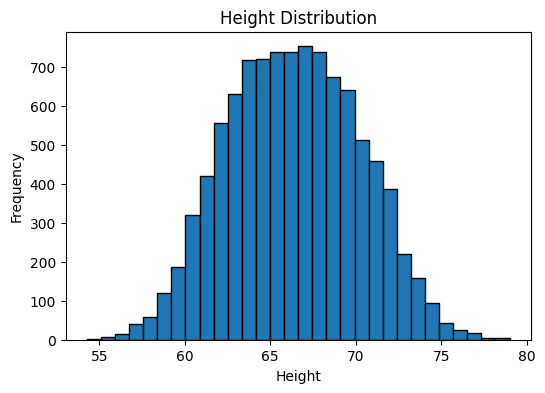

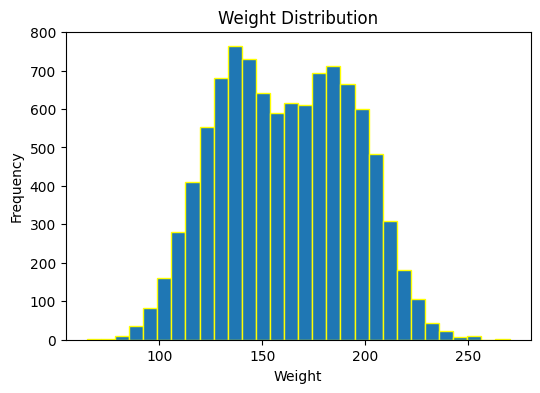

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("weight-height.csv")
print(df.head())

# Display dataset information
print(df.info())

# Histogram for Height
plt.figure(figsize=(6,4))
plt.hist(df["Height"], bins=30, edgecolor='black')
plt.title("Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

# Histogram for Weight
plt.figure(figsize=(6,4))
plt.hist(df["Weight"], bins=30, edgecolor='yellow')
plt.title("Weight Distribution")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.show()

In [5]:
Q1 = df["Weight"].quantile(0.25)
Q3 = df["Weight"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

weight_outliers = df[(df["Weight"] < lower_limit) | (df["Weight"] > upper_limit)]

print("Weight Outliers")
print(weight_outliers)

Weight Outliers
     Gender     Height      Weight
2014   Male  78.998742  269.989699


In [6]:
Q1 = df["Height"].quantile(0.25)
Q3 = df["Height"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

height_outliers = df[(df["Height"] < lower_limit) | (df["Height"] > upper_limit)]

print("Height Outliers")
print(height_outliers)

Height Outliers
      Gender     Height      Weight
994     Male  78.095867  255.690835
1317    Male  78.462053  227.342565
2014    Male  78.998742  269.989699
3285    Male  78.528210  253.889004
3757    Male  78.621374  245.733783
6624  Female  54.616858   71.393749
7294  Female  54.873728   78.606670
9285  Female  54.263133   64.700127


In [8]:
# Create a copy of dataset
df_mean = df.copy()

# Weight outliers
Q1 = df_mean["Weight"].quantile(0.25)
Q3 = df_mean["Weight"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mean_weight = df_mean["Weight"].mean()

df_mean.loc[(df_mean["Weight"] < lower) | (df_mean["Weight"] > upper), "Weight"] = mean_weight

# Height outliers
Q1 = df_mean["Height"].quantile(0.25)
Q3 = df_mean["Height"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

mean_height = df_mean["Height"].mean()

df_mean.loc[(df_mean["Height"] < lower) | (df_mean["Height"] > upper), "Height"] = mean_height

print("Dataset after replacing outliers with Mean")
print(df_mean)

Dataset after replacing outliers with Mean
      Gender     Height      Weight
0       Male  73.847017  241.893563
1       Male  68.781904  162.310473
2       Male  74.110105  212.740856
3       Male  71.730978  220.042470
4       Male  69.881796  206.349801
...      ...        ...         ...
9995  Female  66.172652  136.777454
9996  Female  67.067155  170.867906
9997  Female  63.867992  128.475319
9998  Female  69.034243  163.852461
9999  Female  61.944246  113.649103

[10000 rows x 3 columns]


In [9]:
# Create another copy
df_median = df.copy()

# Weight
Q1 = df_median["Weight"].quantile(0.25)
Q3 = df_median["Weight"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

median_weight = df_median["Weight"].median()

df_median.loc[(df_median["Weight"] < lower) | (df_median["Weight"] > upper), "Weight"] = median_weight

# Height
Q1 = df_median["Height"].quantile(0.25)
Q3 = df_median["Height"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

median_height = df_median["Height"].median()

df_median.loc[(df_median["Height"] < lower) | (df_median["Height"] > upper), "Height"] = median_height

print("Dataset after replacing outliers with Median")
print(df_median)

Dataset after replacing outliers with Median
      Gender     Height      Weight
0       Male  73.847017  241.893563
1       Male  68.781904  162.310473
2       Male  74.110105  212.740856
3       Male  71.730978  220.042470
4       Male  69.881796  206.349801
...      ...        ...         ...
9995  Female  66.172652  136.777454
9996  Female  67.067155  170.867906
9997  Female  63.867992  128.475319
9998  Female  69.034243  163.852461
9999  Female  61.944246  113.649103

[10000 rows x 3 columns]


In [12]:
# Example dataset of Employee salary
import pandas as pd

data = {
    'Employee':['A','B','C','D','E','F','G','H'],
    'Age':[25,28,30,35,29,31,27,33],
    'Salary':[30000,32000,35000,36000,34000,33000,31000,250000],
    'Experience':[2,3,5,8,4,6,3,10]
}

df = pd.DataFrame(data)

print(df)
print(df['Salary'].max())
print(df['Salary'].mean())

  Employee  Age  Salary  Experience
0        A   25   30000           2
1        B   28   32000           3
2        C   30   35000           5
3        D   35   36000           8
4        E   29   34000           4
5        F   31   33000           6
6        G   27   31000           3
7        H   33  250000          10
250000
60125.0


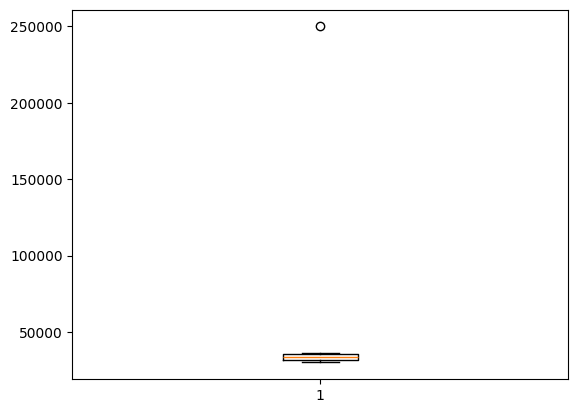

In [13]:
# boxplot
import matplotlib.pyplot as plt

plt.boxplot(df['Salary'])
plt.show()

In [14]:
# Detect Salary Outliers
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

print(df[(df['Salary']<lower)|(df['Salary']>upper)])

  Employee  Age  Salary  Experience
7        H   33  250000          10


In [16]:
# Removing Outliers
df_clean = df[(df['Salary'] >= lower_limit) & (df['Salary'] <= upper_limit)]

print("Dataset after removing outliers:")
print(df_clean)

Dataset after removing outliers:
Empty DataFrame
Columns: [Employee, Age, Salary, Experience]
Index: []
